# Computer Appendix

In [1]:
library(survival)
library(multcomp)

Loading required package: mvtnorm

Loading required package: TH.data

Loading required package: MASS


Attaching package: 'TH.data'


The following object is masked from 'package:MASS':

    geyser




In [2]:
addicts <- read.csv("./data/addicts.csv")

addicts[1:5,]

,id,clinic,status,survt,prison,dose
,<int>,<int>,<int>,<int>,<int>,<int>
1,1,1,1,428,0,50
2,2,1,1,275,1,55
3,3,1,1,262,0,55
4,4,1,1,183,0,30
5,5,1,1,259,1,65


## 生存函数の推定と検定
$$S(t) = P(T > t) = \exp\left( - \int_0^t h(u) \, du \right)$$

In [3]:
Surv(addicts$survt, addicts$status)

  [1]  428   275   262   183   259   714   438   796+  892   393   161+  836 
 [13]  523   612   212   399   771   514   512   624   209   341   299   826+
 [25]  262   566+  368   302   602+  652   293   564+  394   755   591   787+
 [37]  739   550   837   612   581+  523   504   785   774   560   160   482 
 [49]  518   683   147   563   646   899   857   180   452   760   496   258 
 [61]  181   386   439+  563+  337   613+  192   405+  667   905+  247   821 
 [73]  821   517+  346+  294   244    95   376   212    96   532   522   679 
 [85]  408+  840+  148+  168   489   541+  205   475+  237   517   749   150 
 [97]  465   708   713+  146+  450   555+  460    53+  122    35   532+  684+
[109]  769+  591+  769+  609+  932+  932+  587+   26    72+  641+  367+  633+
[121]  661   232    13   563+  969+ 1052+  944+  881+  190    79   884+  170 
[133]  286   358+  326+  769+  161   564+  268   611+  322  1076+    2+  788+
[145]  575+  109   730+  790+  456+  231   143    86+ 1021+  684

In [4]:
summary(survfit(Surv(addicts$survt, addicts$status) ~ 1))

Call: survfit(formula = Surv(addicts$survt, addicts$status) ~ 1)

 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    7    236       1    0.996 0.00423       0.9875        1.000
   13    235       1    0.992 0.00597       0.9799        1.000
   17    234       1    0.987 0.00729       0.9731        1.000
   19    233       1    0.983 0.00840       0.9667        1.000
   26    232       1    0.979 0.00937       0.9606        0.997
   29    229       1    0.975 0.01026       0.9546        0.995
   30    228       1    0.970 0.01107       0.9488        0.992
   33    227       1    0.966 0.01182       0.9431        0.989
   35    226       2    0.957 0.01317       0.9320        0.984
   37    224       1    0.953 0.01379       0.9265        0.981
   41    223       2    0.945 0.01493       0.9158        0.974
   47    221       1    0.940 0.01546       0.9105        0.971
   49    220       1    0.936 0.01597       0.9053        0.968
   50    219       1    0.932 0.01646 

In [5]:
Y <- Surv(addicts$survt, addicts$status)
kmfit1 <- survfit(Surv(addicts$survt, addicts$status) ~ 1)

summary(kmfit1, times = 365)

Call: survfit(formula = Surv(addicts$survt, addicts$status) ~ 1)

 time n.risk n.event survival std.err lower 95% CI upper 95% CI
  365    122      87    0.606  0.0331        0.545        0.675

In [6]:
kmfit2 <- survfit(Y ~ addicts$clinic)
summary(kmfit2, times=100*(0:10))

Call: survfit(formula = Y ~ addicts$clinic)

                addicts$clinic=1 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    0    163       0   1.0000  0.0000      1.00000        1.000
  100    137      20   0.8746  0.0262      0.82467        0.928
  200    110      20   0.7420  0.0353      0.67601        0.814
  300     87      20   0.6046  0.0399      0.53120        0.688
  400     68      14   0.5025  0.0415      0.42741        0.591
  500     53       9   0.4319  0.0418      0.35719        0.522
  600     30      16   0.2951  0.0403      0.22570        0.386
  700     20       8   0.2113  0.0383      0.14818        0.301
  800     10       8   0.1268  0.0326      0.07660        0.210
  900      1       7   0.0181  0.0172      0.00283        0.116

                addicts$clinic=2 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    0     75       0    1.000  0.0000        1.000        1.000
  100     66       5    0.932  0.0294        0.876    

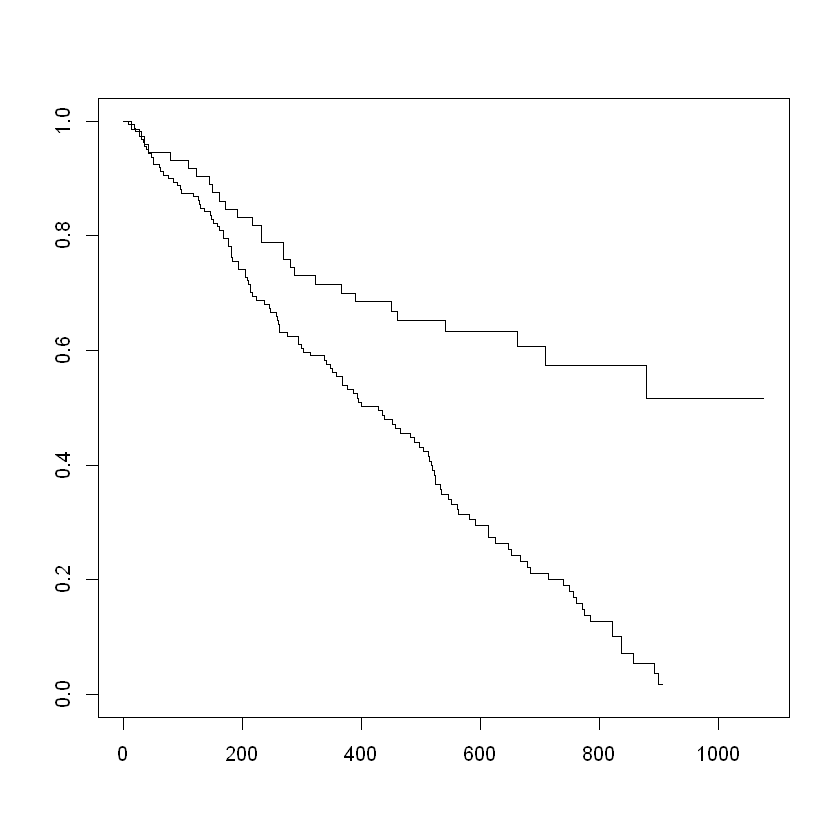

In [7]:
plot(kmfit2)

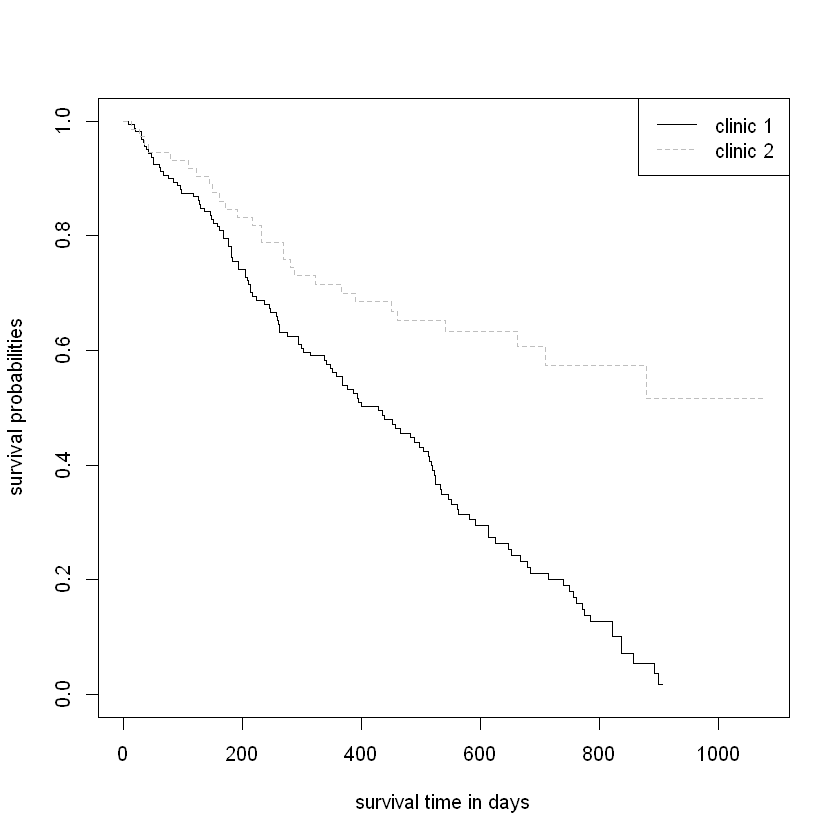

In [8]:
plot(kmfit2, lty = c("solid", "dashed"), col = c("black", "grey"), xlab = "survival time in days", ylab = "survival probabilities")
legend("topright", c("clinic 1", "clinic 2"), lty = c("solid", "dashed"), col = c("black", "grey"))

log-rank検定

In [9]:
survdiff(Surv(survt, status) ~ clinic, data=addicts)

Call:
survdiff(formula = Surv(survt, status) ~ clinic, data = addicts)

           N Observed Expected (O-E)^2/E (O-E)^2/V
clinic=1 163      122     90.9      10.6      27.9
clinic=2  75       28     59.1      16.4      27.9

 Chisq= 27.9  on 1 degrees of freedom, p= 1e-07 

Gehan-Wilcoxon (Peto-Peto)検定

In [10]:
survdiff(Surv(survt, status) ~ clinic, data=addicts, rho = 1)

Call:
survdiff(formula = Surv(survt, status) ~ clinic, data = addicts, 
    rho = 1)

           N Observed Expected (O-E)^2/E (O-E)^2/V
clinic=1 163     77.3     61.4      4.08      15.8
clinic=2  75     19.9     35.7      7.03      15.8

 Chisq= 15.8  on 1 degrees of freedom, p= 7e-05 

層化log-rank検定

In [11]:
survdiff(Surv(survt, status) ~ clinic + strata(prison), data=addicts)

Call:
survdiff(formula = Surv(survt, status) ~ clinic + strata(prison), 
    data = addicts)

           N Observed Expected (O-E)^2/E (O-E)^2/V
clinic=1 163      122     91.7      10.0      26.9
clinic=2  75       28     58.3      15.8      26.9

 Chisq= 26.9  on 1 degrees of freedom, p= 2e-07 

## PH仮定の検討
対数対数プロット

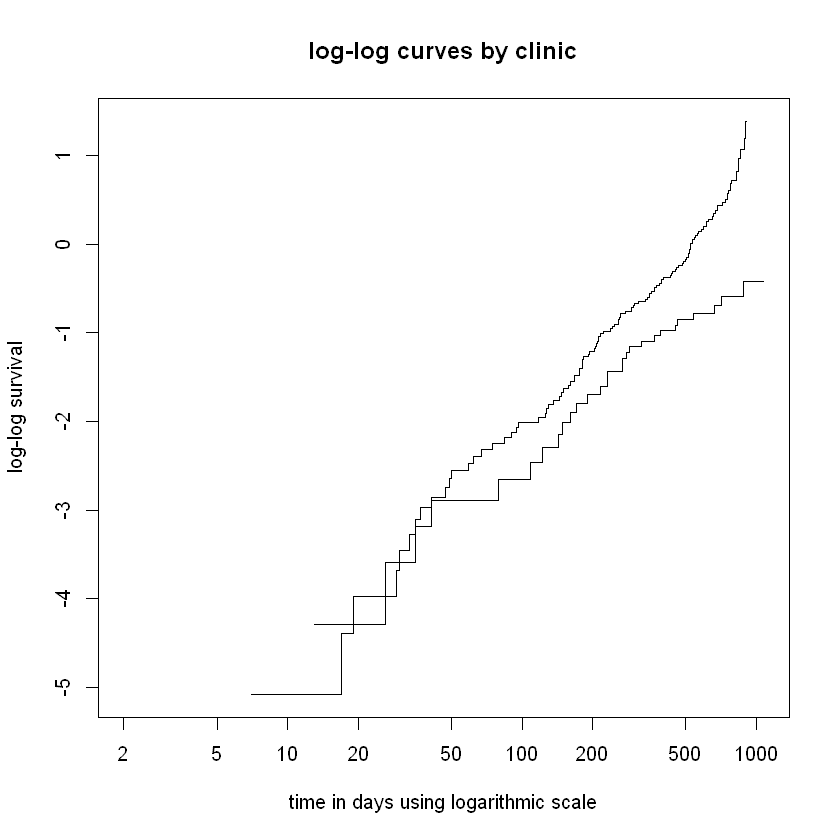

In [12]:
plot(kmfit2, fun = "cloglog", xlab = "time in days using logarithmic scale", ylab = "log-log survival", main = "log-log curves by clinic")

In [13]:
kmfit3 <- summary(kmfit2)

names(kmfit3)

[1] "n"             "time"          "n.risk"        "n.event"      
 [5] "n.censor"      "surv"          "std.err"       "cumhaz"       
 [9] "std.chaz"      "strata"        "type"          "logse"        
[13] "conf.int"      "conf.type"     "lower"         "upper"        
[17] "t0"            "call"          "table"         "rmean.endtime"

In [14]:
kmfit4 <- data.frame(kmfit3$strata, kmfit3$time, kmfit3$surv)
names(kmfit4) <- c("clinic", "time", "survival")

kmfit4[1:5, ]

,clinic,time,survival
,<fct>,<dbl>,<dbl>
1,addicts$clinic=1,7,0.9938272
2,addicts$clinic=1,17,0.9876543
3,addicts$clinic=1,19,0.9814815
4,addicts$clinic=1,29,0.9752300
5,addicts$clinic=1,30,0.9689785


In [15]:
clinic1 <- kmfit4[kmfit4$clinic == "addicts$clinic=1",]
clinic2 <- kmfit4[kmfit4$clinic == "addicts$clinic=2",]

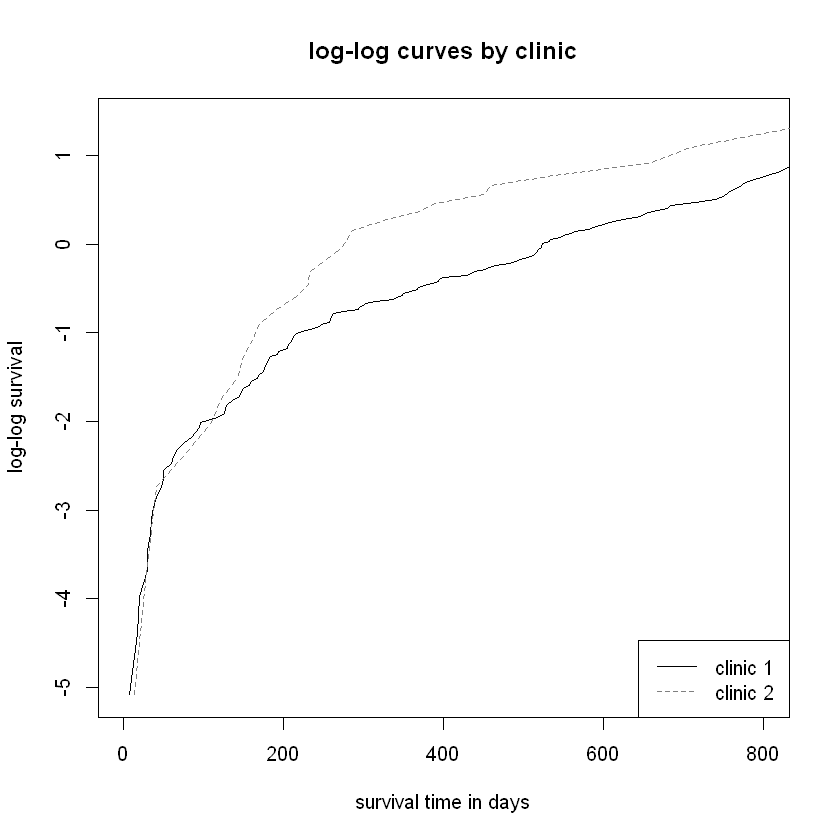

In [16]:
plot(clinic1$time, log(-log(clinic1$survival)), xlab = "survival time in days", ylab = "log-log survival", "xlim" = c(0, 800), col = "black", type = "l", lty = "solid", main = "log-log curves by clinic")
par(new = T)
plot(clinic2$time, log(-log(clinic2$survival)), axes = F, xlab = "", ylab = "", "xlim" = c(0, 800), col = "grey50", type = "l", lty = "dashed")
legend("bottomright", c("clinic 1", "clinic 2"), lty = c("solid", "dashed"), col = c("black", "grey50"))
par(new = F)

## Cox比例ハザードモデル
$$ h(t) = h_0(t) \exp \left( \sum_i \beta_i X_i \right) $$

In [17]:
Y <- Surv(addicts$survt, addicts$status == 1)
coxph(Y ~ prison + dose + clinic, data = addicts)
# coxph(Y ~ prison + dose + clinic, data = addicts, method = "efron")
# coxph(Y ~ prison + dose + clinic, data = addicts, method = "breslow")
# coxph(Y ~ prison + dose + clinic, data = addicts, method = "exact")

Call:
coxph(formula = Y ~ prison + dose + clinic, data = addicts)

            coef exp(coef)  se(coef)      z        p
prison  0.326555  1.386184  0.167225  1.953   0.0508
dose   -0.035369  0.965249  0.006379 -5.545 2.94e-08
clinic -1.009896  0.364257  0.214889 -4.700 2.61e-06

Likelihood ratio test=64.56  on 3 df, p=6.229e-14
n= 238, number of events= 150 

In [18]:
summary(coxph(Y ~ prison + dose + clinic, data = addicts))

Call:
coxph(formula = Y ~ prison + dose + clinic, data = addicts)

  n= 238, number of events= 150 

            coef exp(coef)  se(coef)      z Pr(>|z|)    
prison  0.326555  1.386184  0.167225  1.953   0.0508 .  
dose   -0.035369  0.965249  0.006379 -5.545 2.94e-08 ***
clinic -1.009896  0.364257  0.214889 -4.700 2.61e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

       exp(coef) exp(-coef) lower .95 upper .95
prison    1.3862     0.7214    0.9988    1.9238
dose      0.9652     1.0360    0.9533    0.9774
clinic    0.3643     2.7453    0.2391    0.5550

Concordance= 0.665  (se = 0.025 )
Likelihood ratio test= 64.56  on 3 df,   p=6e-14
Wald test            = 54.12  on 3 df,   p=1e-11
Score (logrank) test = 56.32  on 3 df,   p=4e-12


交互作用と尤度比検定

In [19]:
mod1 <- coxph(Y ~ prison + dose + clinic, data = addicts)
mod2 <- coxph(Y ~ prison + dose + clinic + clinic*prison + clinic*dose, data = addicts)
mod2

Call:
coxph(formula = Y ~ prison + dose + clinic + clinic * prison + 
    clinic * dose, data = addicts)

                  coef exp(coef) se(coef)      z      p
prison         1.19238   3.29491  0.54141  2.202 0.0276
dose          -0.01916   0.98102  0.01935 -0.990 0.3220
clinic         0.17955   1.19668  0.89330  0.201 0.8407
prison:clinic -0.73832   0.47791  0.43151 -1.711 0.0871
dose:clinic   -0.01396   0.98614  0.01433 -0.974 0.3300

Likelihood ratio test=68.18  on 5 df, p=2.452e-13
n= 238, number of events= 150 

In [20]:
names(mod2)

[1] "coefficients"      "var"               "loglik"           
 [4] "score"             "iter"              "linear.predictors"
 [7] "residuals"         "means"             "method"           
[10] "n"                 "nevent"            "terms"            
[13] "assign"            "wald.test"         "concordance"      
[16] "y"                 "timefix"           "formula"          
[19] "call"

In [21]:
mod2$loglik

[1] -705.5393 -671.4500

In [22]:
LRT <- (-2) * (mod1$loglik[2] - mod2$loglik[2])
Pvalue <- 1 - pchisq(LRT,df = 2)
Pvalue

[1] 0.1638006

In [23]:
lrt.surv <- function(mod.full, mod.reduced, df){
  lrts <- (-2) * (mod.full$loglik[2] - mod.reduced$loglik[2])
  pvalue <- 1 - pchisq(lrts,df = 2)
 return(pvalue)
}

lrt.surv(mod1, mod2, 2)

[1] 0.1638006

## 層化Coxモデル
層による係数変化（層とする変数による交互作用）がないモデル：
$$ h_g(t) = h_{0g}(t) \exp \left( \sum_i \beta_i X_i \right) $$

In [24]:
Y <- Surv(addicts$survt, addicts$status == 1)
coxph(Y ~ prison + dose + strata(clinic), data = addicts)

Call:
coxph(formula = Y ~ prison + dose + strata(clinic), data = addicts)

            coef exp(coef)  se(coef)      z        p
prison  0.389605  1.476397  0.168930  2.306   0.0211
dose   -0.035115  0.965495  0.006465 -5.432 5.59e-08

Likelihood ratio test=33.91  on 2 df, p=4.322e-08
n= 238, number of events= 150 

交互作用を入れた場合
$$ h_g(t) = h_{0g}(t) \exp \left( \sum_i \beta_{ig} X_i \right) $$

In [25]:
res <- coxph(Y ~ prison + dose + clinic:prison + clinic:dose + strata(clinic), data = addicts)
res

Call:
coxph(formula = Y ~ prison + dose + clinic:prison + clinic:dose + 
    strata(clinic), data = addicts)

                   coef exp(coef)  se(coef)      z      p
prison         1.085836  2.961914  0.538636  2.016 0.0438
dose          -0.034635  0.965958  0.019797 -1.750 0.0802
prison:clinic -0.582989  0.558227  0.428135 -1.362 0.1733
dose:clinic   -0.001164  0.998837  0.014570 -0.080 0.9363

Likelihood ratio test=35.77  on 4 df, p=3.222e-07
n= 238, number of events= 150 

`clinic = 2`における`pr=1/0`のハザード比を出す方法．
1. 係数の線型結合を計算する

In [26]:
lincom <- glht(res, linfct = c("prison + 2 * prison:clinic = 0"))
confint(lincom)


	 Simultaneous Confidence Intervals

Fit: coxph(formula = Y ~ prison + dose + clinic:prison + clinic:dose + 
    strata(clinic), data = addicts)

Quantile = 1.96
95% family-wise confidence level
 

Linear Hypotheses:
                                Estimate lwr      upr     
prison + 2 * prison:clinic == 0 -0.08014 -0.83337  0.67308


2. 係数の定義を変更する

In [27]:
addicts$clinic2 <- addicts$clinic - 2
summary(coxph(Y ~ prison + dose + clinic2:prison + clinic2:dose + strata(clinic2), data = addicts))

Call:
coxph(formula = Y ~ prison + dose + clinic2:prison + clinic2:dose + 
    strata(clinic2), data = addicts)

  n= 238, number of events= 150 

                    coef exp(coef)  se(coef)      z Pr(>|z|)   
prison         -0.080143  0.922985  0.384305 -0.209  0.83481   
dose           -0.036964  0.963711  0.012346 -2.994  0.00275 **
prison:clinic2 -0.582989  0.558227  0.428135 -1.362  0.17329   
dose:clinic2   -0.001164  0.998837  0.014570 -0.080  0.93632   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

               exp(coef) exp(-coef) lower .95 upper .95
prison            0.9230      1.083    0.4346    1.9603
dose              0.9637      1.038    0.9407    0.9873
prison:clinic2    0.5582      1.791    0.2412    1.2919
dose:clinic2      0.9988      1.001    0.9707    1.0278

Concordance= 0.649  (se = 0.026 )
Likelihood ratio test= 35.77  on 4 df,   p=3e-07
Wald test            = 34.09  on 4 df,   p=7e-07
Score (logrank) test = 34.97  on 4 df,   p=5e-07


## PHの検討

In [28]:
Y <- Surv(addicts$survt, addicts$status == 1)
mod1 <- coxph(Y ~ prison + dose + clinic, data = addicts)
cox.zph(mod1, transform = rank)

        chisq df       p
prison  0.853  1 0.35567
dose    0.608  1 0.43557
clinic 11.302  1 0.00077
GLOBAL 12.465  3 0.00595

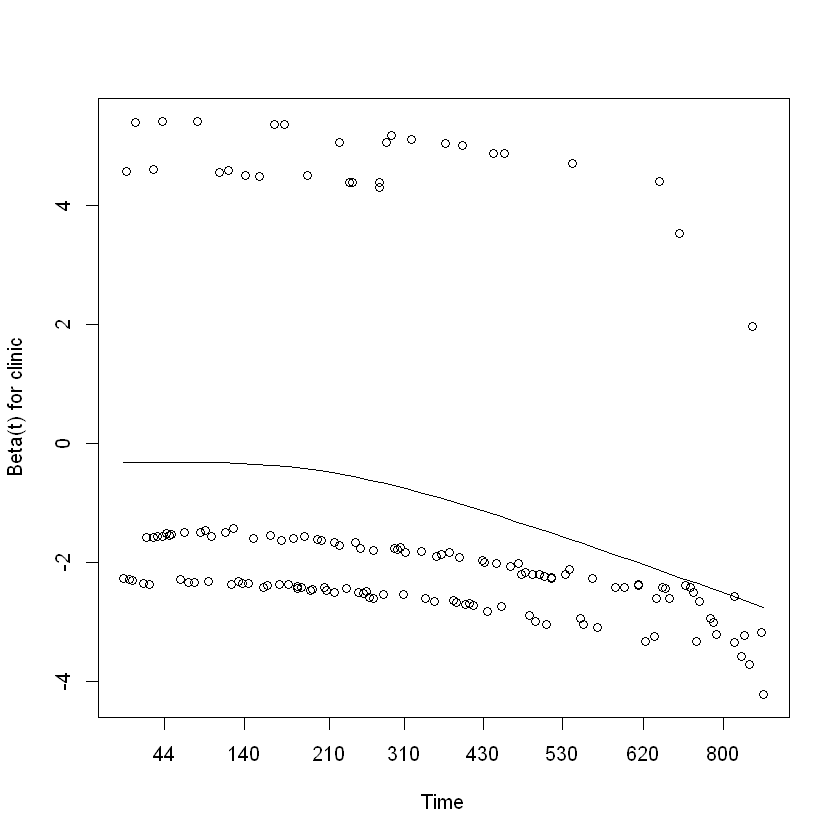

In [29]:
plot(cox.zph(mod1, transform = rank), se = F, var = "clinic")

## Cox調整生存曲線
KM曲線とは違う

In [30]:
Y <- Surv(addicts$survt, addicts$status == 1)
mod1 <- coxph(Y ~ prison + dose + clinic, data = addicts)

In [31]:
pattern1 <- data.frame(prison = 0, dose = 70, clinic = 2)
pattern1

prison,dose,clinic
<dbl>,<dbl>,<dbl>
0,70,2


In [32]:
summary(survfit(mod1, pattern1))

Call: survfit(formula = mod1, newdata = pattern1)

 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    7    236       1    0.999 0.00105        0.997        1.000
   13    235       1    0.998 0.00154        0.995        1.000
   17    234       1    0.997 0.00193        0.993        1.000
   19    233       1    0.996 0.00229        0.991        1.000
   26    232       1    0.995 0.00263        0.990        1.000
   29    229       1    0.994 0.00296        0.988        1.000
   30    228       1    0.993 0.00328        0.986        0.999
   33    227       1    0.992 0.00359        0.985        0.999
   35    226       2    0.989 0.00419        0.981        0.998
   37    224       1    0.988 0.00448        0.980        0.997
   41    223       2    0.986 0.00506        0.976        0.996
   47    221       1    0.985 0.00535        0.975        0.996
   49    220       1    0.984 0.00563        0.973        0.995
   50    219       1    0.983 0.00592        0.971   

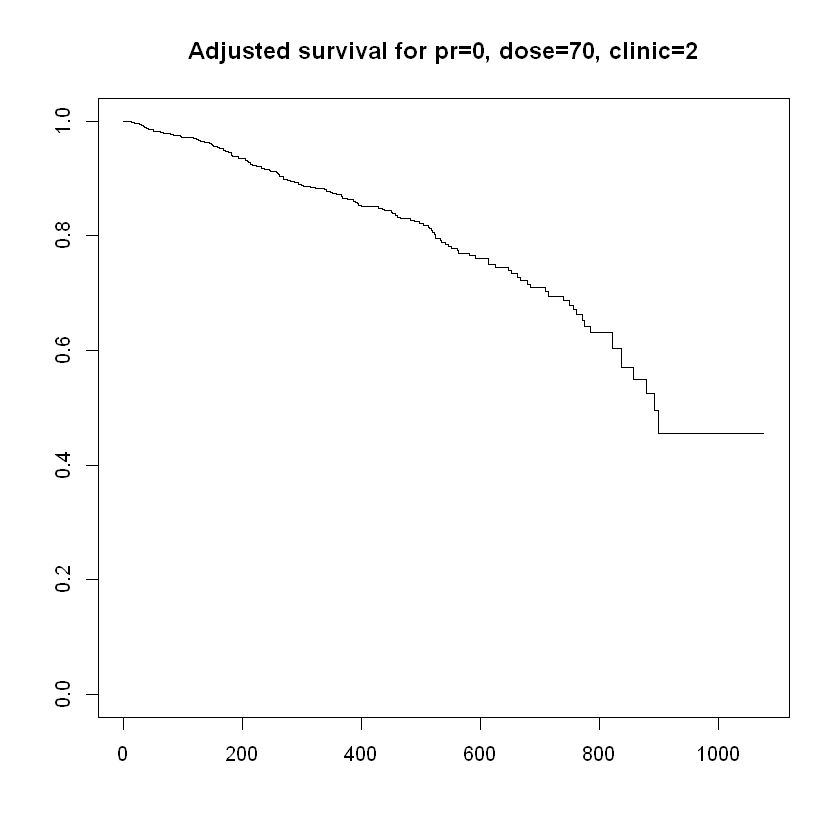

In [33]:
plot(survfit(mod1, pattern1), conf.int = F, main = "Adjusted survival for pr=0, dose=70, clinic=2")

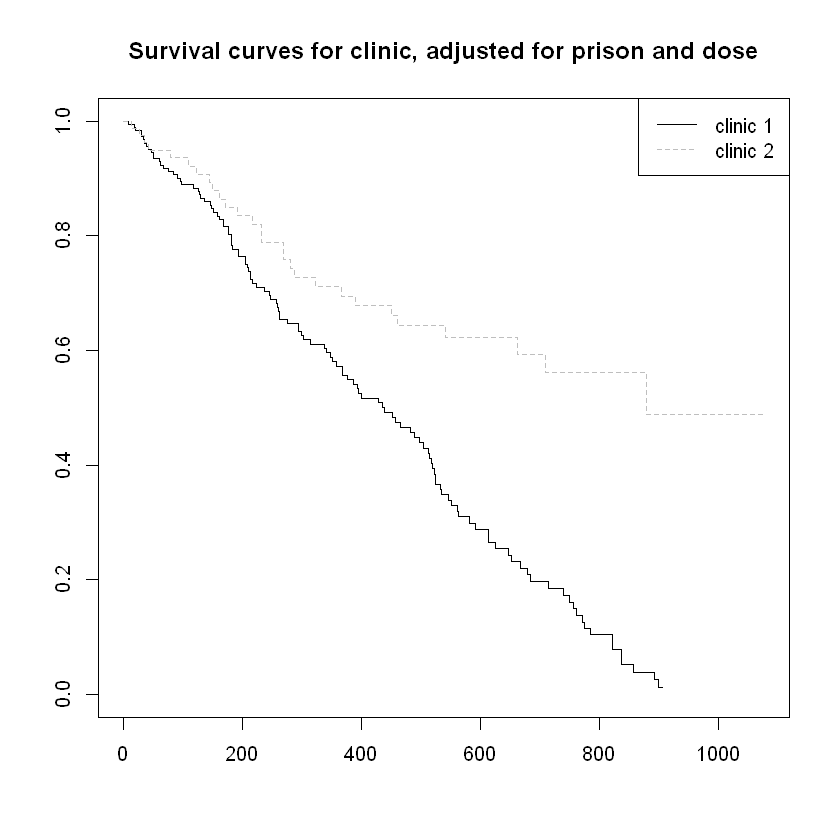

In [34]:
mod3 <- coxph(Y ~ prison + dose + strata(clinic), data = addicts)
pattern2 <- data.frame(prison = .46, dose = 60.4)
plot(survfit(mod3, pattern2), conf.int = F, lty = c("solid", "dashed"), col = c("black", "grey"), main = "Survival curves for clinic, adjusted for prison and dose")
legend("topright", c("clinic 1", "clinic 2"), lty = c("solid", "dashed"), col = c("black", "grey"))

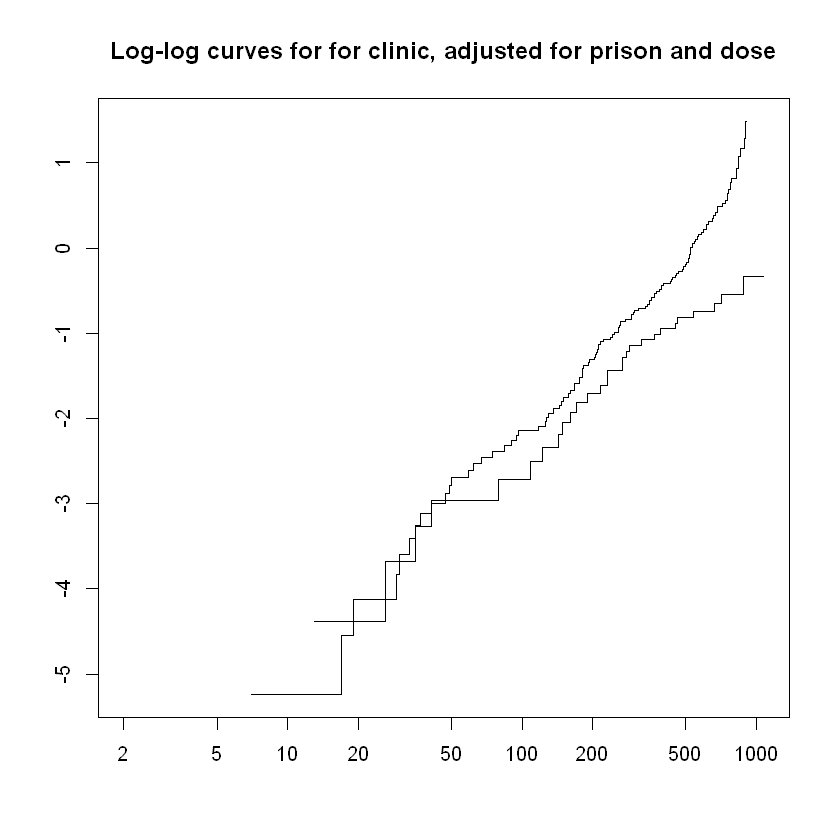

In [35]:
plot(survfit(mod3, pattern2), fun = "cloglog", main = "Log-log curves for for clinic, adjusted for prison and dose")

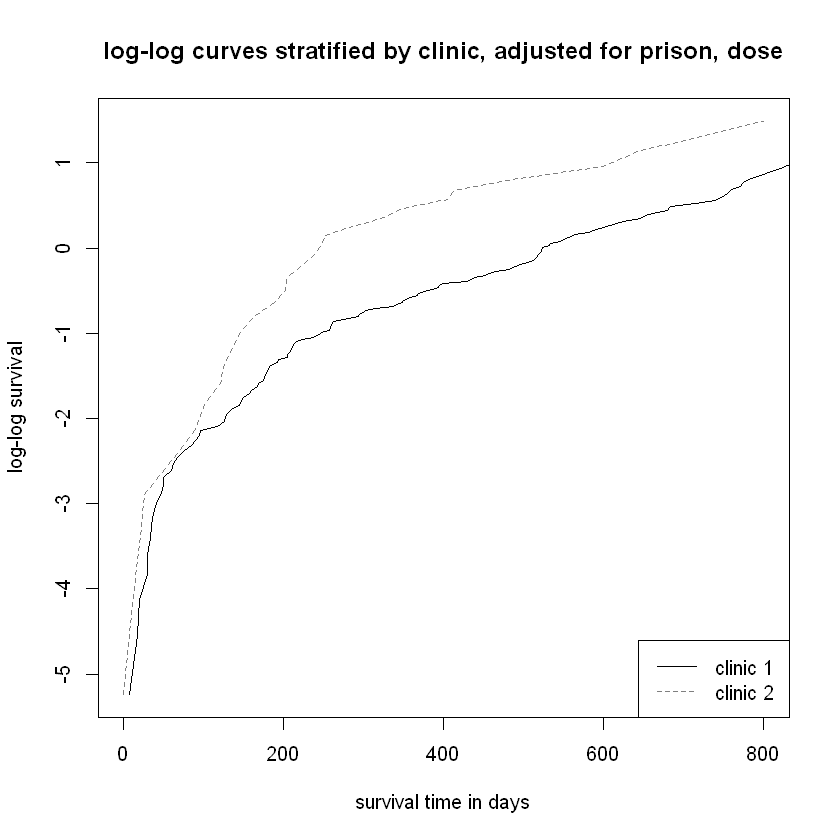

In [36]:
sum.mod3 <- summary(survfit(mod3, newdata = pattern2))
sum.mod4 <- data.frame(sum.mod3$strata, sum.mod3$time, sum.mod3$surv)
colnames(sum.mod4) <- c("clinic", "time", "survival")
clinic1 <- sum.mod4[sum.mod4$clinic == "clinic=1",]
clinic2 <- sum.mod4[sum.mod4$clinic == "clinic=2",]

plot(clinic1$time, log(-log(clinic1$survival)), xlab = "survival time in days", ylab = "log-log survival", xlim = c(0, 800), col = "black", type = "l", lty = "solid", main = "log-log curves stratified by clinic, adjusted for prison, dose")
par(new = T)
plot(clinic2$time, log(-log(clinic2$survival)), axes = F, xlab = "", ylab = "", col = "grey50", type = "l", lty = "dashed")
legend("bottomright", c("clinic 1", "clinic 2"), lty = c("solid", "dashed"), col = c("black", "grey50"))
par(new = F)

## 拡張Coxモデル
時間依存性変数
$$ h(t) = h_0(t) \exp \left( \sum_i \beta_i X_i(t) \right) $$

In [37]:
addicts.cp <- survSplit(addicts, cut = addicts$survt[addicts$status==1], end="survt", event="status", start="start", id = "id_new")
head(addicts.cp)

,id,clinic,prison,dose,clinic2,id_new,start,survt,status
,<int>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
1,1,1,0,50,-1,1,0,7,0
2,1,1,0,50,-1,1,7,13,0
3,1,1,0,50,-1,1,13,17,0
4,1,1,0,50,-1,1,17,19,0
5,1,1,0,50,-1,1,19,26,0
6,1,1,0,50,-1,1,26,29,0


In [38]:
addicts.cp$logtdose <- addicts.cp$dose * log(addicts.cp$survt)
addicts.cp[addicts.cp$id_new == 106, c("id_new", "start", "survt", "status", "dose", "logtdose")]

,id_new,start,survt,status,dose,logtdose
,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
9802,106,0,7,0,40,77.83641
9803,106,7,13,0,40,102.59797
9804,106,13,17,0,40,113.32853
9805,106,17,19,0,40,117.77756
9806,106,19,26,0,40,130.32386
9807,106,26,29,0,40,134.69183
9808,106,29,30,0,40,136.04790
9809,106,30,33,0,40,139.86030
9810,106,33,35,1,40,142.21392


In [39]:
coxph(Surv(addicts.cp$start, addicts.cp$survt, addicts.cp$status) ~ prison + dose + clinic + logtdose + cluster(id), data = addicts.cp)

Call:
coxph(formula = Surv(addicts.cp$start, addicts.cp$survt, addicts.cp$status) ~ 
    prison + dose + clinic + logtdose, data = addicts.cp, cluster = id)

              coef exp(coef)  se(coef) robust se      z       p
prison    0.340633  1.405837  0.167474  0.159717  2.133 0.03295
dose     -0.082625  0.920696  0.035984  0.029601 -2.791 0.00525
clinic   -1.019875  0.360640  0.215416  0.236365 -4.315 1.6e-05
logtdose  0.008615  1.008652  0.006455  0.005248  1.642 0.10068

Likelihood ratio test=66.35  on 4 df, p=1.338e-13
n= 18708, number of events= 150 

Heaviside階段函数で365未満・以降に分ける

In [40]:
addicts.cp365 <- survSplit(addicts, cut=365, end = "survt", event = "status", start = "start", id = "id_new")
addicts.cp365$hv1 <- addicts.cp365$clinic * (addicts.cp365$start < 365)
addicts.cp365$hv2 <- addicts.cp365$clinic * (addicts.cp365$start >= 365)
addicts.cp365 <- addicts.cp365[order(addicts.cp365$id_new, addicts.cp365$start),]

addicts.cp365[1:10, c("id_new", "start", "survt", "status", "clinic", "hv1", "hv2")]

,id_new,start,survt,status,clinic,hv1,hv2
,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
1,1,0,365,0,1,1,0
2,1,365,428,1,1,0,1
3,2,0,275,1,1,1,0
4,3,0,262,1,1,1,0
5,4,0,183,1,1,1,0
6,5,0,259,1,1,1,0
7,6,0,365,0,1,1,0
8,6,365,714,1,1,0,1
9,7,0,365,0,1,1,0


In [41]:
Y365 <- Surv(addicts.cp365$start, addicts.cp365$survt, addicts.cp365$status)
coxph(Y365 ~ prison + dose + hv1 + hv2 + cluster(id), data = addicts.cp365)
# coxph(Y365 ~ prison + dose + hv1 + hv2 + cluster(id), data = addicts.cp365, method = "breslow")

Call:
coxph(formula = Y365 ~ prison + dose + hv1 + hv2, data = addicts.cp365, 
    cluster = id)

            coef exp(coef)  se(coef) robust se      z        p
prison  0.377951  1.459291  0.168415  0.167650  2.254   0.0242
dose   -0.035480  0.965142  0.006435  0.006520 -5.442 5.27e-08
hv1    -0.459373  0.631679  0.255290  0.259983 -1.767   0.0772
hv2    -1.830517  0.160331  0.385954  0.398376 -4.595 4.33e-06

Likelihood ratio test=74.25  on 4 df, p=2.868e-15
n= 360, number of events= 150 

Heaviside階段函数を1つだけにする

In [42]:
res <- coxph(Y365 ~ prison + dose + clinic + hv2 + cluster(id), data = addicts.cp365)
res

Call:
coxph(formula = Y365 ~ prison + dose + clinic + hv2, data = addicts.cp365, 
    cluster = id)

            coef exp(coef)  se(coef) robust se      z        p
prison  0.377951  1.459291  0.168415  0.167650  2.254  0.02417
dose   -0.035480  0.965142  0.006435  0.006520 -5.442 5.27e-08
clinic -0.459373  0.631679  0.255290  0.259983 -1.767  0.07724
hv2    -1.371144  0.253816  0.461403  0.470540 -2.914  0.00357

Likelihood ratio test=74.25  on 4 df, p=2.868e-15
n= 360, number of events= 150 

$t\geq365$以降は`clinic + hv2`

In [43]:
lincom <- glht(res, linfct = c("clinic + hv2 = 0"))
confint(lincom)


	 Simultaneous Confidence Intervals

Fit: coxph(formula = Y365 ~ prison + dose + clinic + hv2, data = addicts.cp365, 
    cluster = id)

Quantile = 1.96
95% family-wise confidence level
 

Linear Hypotheses:
                  Estimate lwr     upr    
clinic + hv2 == 0 -1.8305  -2.6113 -1.0497


ハザード比

In [44]:
exp(confint(lincom)$confint)

,Estimate,lwr,upr
clinic + hv2,0.1603306,0.07343755,0.3500374


## パラメトリックモデル
指数モデル
$$ h(t) = \lambda $$

In [45]:
modpar1 <- survreg(Surv(addicts$survt, addicts$status) ~ prison + dose + clinic, data = addicts, dist = "exponential")
summary(modpar1)


Call:
survreg(formula = Surv(addicts$survt, addicts$status) ~ prison + 
    dose + clinic, data = addicts, dist = "exponential")
               Value Std. Error     z       p
(Intercept)  3.68434    0.43072  8.55 < 2e-16
prison      -0.25265    0.16489 -1.53    0.13
dose         0.02892    0.00614  4.71 2.5e-06
clinic       0.88058    0.21063  4.18 2.9e-05

Scale fixed at 1 

Exponential distribution
Loglik(model)= -1094   Loglik(intercept only)= -1118.9
	Chisq= 49.91 on 3 degrees of freedom, p= 8.3e-11 
Number of Newton-Raphson Iterations: 5 
n= 238 


Weibullモデル
$$ h(t) = \lambda p t^{p-1} $$

In [46]:
modpar2 <- survreg(Surv(addicts$survt, addicts$status) ~ prison + dose + clinic, data = addicts, dist = "weibull")
summary(modpar2)


Call:
survreg(formula = Surv(addicts$survt, addicts$status) ~ prison + 
    dose + clinic, data = addicts, dist = "weibull")
               Value Std. Error     z       p
(Intercept)  4.10485    0.32806 12.51 < 2e-16
prison      -0.22947    0.12079 -1.90   0.057
dose         0.02443    0.00459  5.32 1.0e-07
clinic       0.70904    0.15722  4.51 6.5e-06
Log(scale)  -0.31495    0.06756 -4.66 3.1e-06

Scale= 0.73 

Weibull distribution
Loglik(model)= -1084.5   Loglik(intercept only)= -1114.9
	Chisq= 60.89 on 3 degrees of freedom, p= 3.8e-13 
Number of Newton-Raphson Iterations: 7 
n= 238 


上記の`Scale`は$\gamma = 1/p$

In [47]:
pattern1 <- data.frame(prison = 1, dose = 50, clinic = 1)
pct <- c(.25, .50, .75)
days <- predict(modpar2, newdata = pattern1, type = "quantile", p = pct)
cbind(pct, days)

pct,days
0.25,133.8074
0.50,254.2196
0.75,421.6070


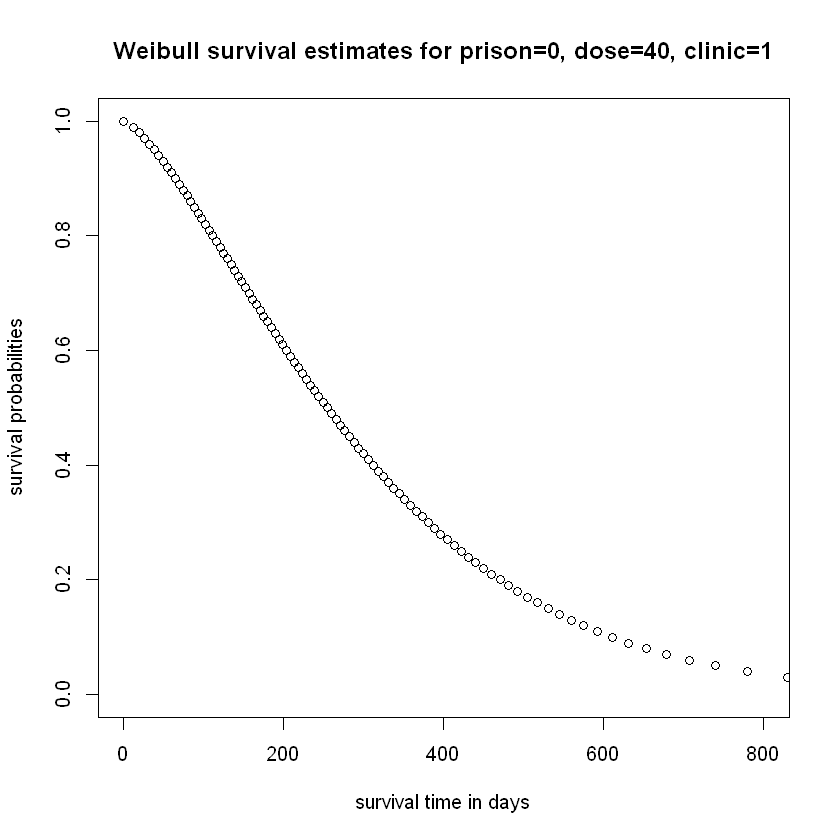

In [48]:
pct2 <- 0:100/100
days2 <- predict(modpar2, newdata = pattern1, type = "quantile", p = pct2)
survival <- 1 - pct2
plot(days2, survival, xlab = "survival time in days", ylab = "survival probabilities", main = "Weibull survival estimates for prison=0, dose=40, clinic=1", xlim = c(0, 800))

対数ロジスティックモデル
$$ h(t) = \frac{\lambda p t^{p-1}}{1 + \lambda t^{p}} $$

In [49]:
modpar3 <- survreg(Surv(addicts$survt, addicts$status) ~ prison + dose + clinic, data = addicts, dist = "loglogistic")
summary(modpar3)


Call:
survreg(formula = Surv(addicts$survt, addicts$status) ~ prison + 
    dose + clinic, data = addicts, dist = "loglogistic")
               Value Std. Error     z       p
(Intercept)  3.56327    0.38945  9.15 < 2e-16
prison      -0.29127    0.14396 -2.02 0.04305
dose         0.03161    0.00552  5.73 1.0e-08
clinic       0.58060    0.17157  3.38 0.00071
Log(scale)  -0.53314    0.06863 -7.77 7.9e-15

Scale= 0.587 

Log logistic distribution
Loglik(model)= -1093.9   Loglik(intercept only)= -1120
	Chisq= 52.18 on 3 degrees of freedom, p= 2.7e-11 
Number of Newton-Raphson Iterations: 4 
n= 238 


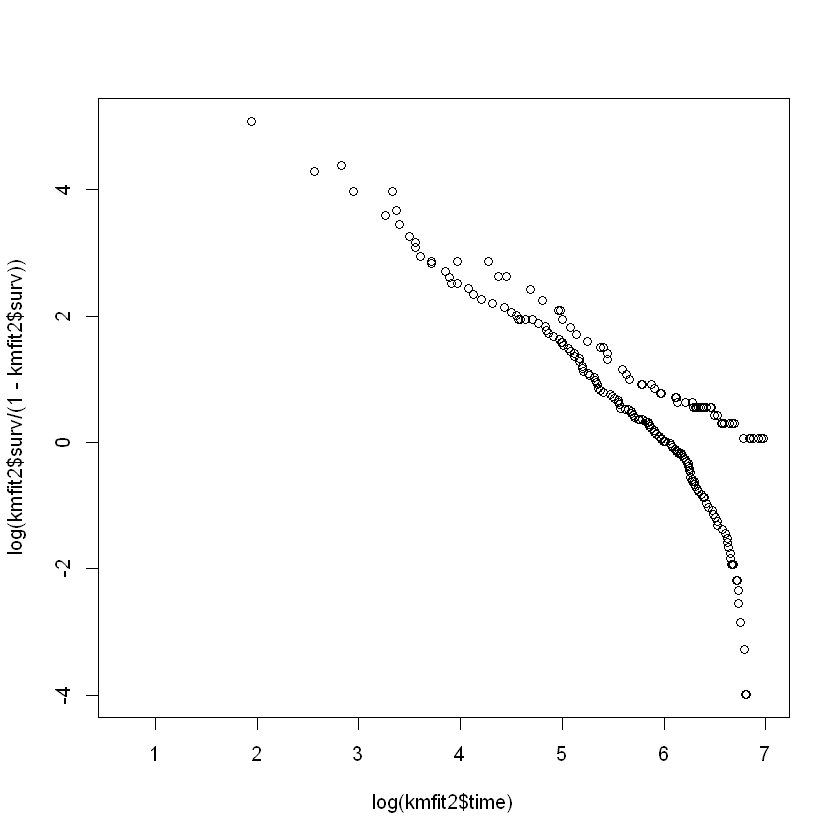

In [50]:
plot(log(kmfit2$time), log(kmfit2$surv / (1 - kmfit2$surv)))

## Frailyモデル
$$ h_\alpha(t) = \alpha h(t) , \quad S_\alpha(t) = [S(t)]^\alpha , \text{Exp}(\alpha) = 1, \quad \text{Var}(\alpha) = \theta $$

In [51]:
Y <- Surv(addicts$survt, addicts$status==1)
coxph(Y ~ prison + dose + strata(clinic), data = addicts)

Call:
coxph(formula = Y ~ prison + dose + strata(clinic), data = addicts)

            coef exp(coef)  se(coef)      z        p
prison  0.389605  1.476397  0.168930  2.306   0.0211
dose   -0.035115  0.965495  0.006465 -5.432 5.59e-08

Likelihood ratio test=33.91  on 2 df, p=4.322e-08
n= 238, number of events= 150 

In [52]:
coxph(Y ~ prison + dose + strata(clinic) + frailty(id, distribution = "gamma"), data = addicts)

Warning message in coxpenal.fit(X, Y, istrat, offset, init = init, control, weights = weights, :
"Inner loop failed to coverge for iterations 2"


Call:
coxph(formula = Y ~ prison + dose + strata(clinic) + frailty(id, 
    distribution = "gamma"), data = addicts)

                              coef se(coef)      se2    Chisq   DF       p
prison                     0.39003  0.16916  0.16893  5.31590 1.00   0.021
dose                      -0.03517  0.00647  0.00647 29.50946 1.00 5.6e-08
frailty(id, distribution                              0.34134 0.32   0.314

Iterations: 5 outer, 41 Newton-Raphson
     Variance of random effect= 0.00227   I-likelihood = -597.5 
Degrees of freedom for terms= 1.0 1.0 0.3 
Likelihood ratio test=34.6  on 2.32 df, p=5e-08
n= 238, number of events= 150 

In [53]:
coxph(Y ~ prison + dose, data = addicts)

Call:
coxph(formula = Y ~ prison + dose, data = addicts)

           coef exp(coef) se(coef)      z        p
prison  0.18965   1.20883  0.16427  1.155    0.248
dose   -0.03608   0.96457  0.00600 -6.013 1.83e-09

Likelihood ratio test=38.21  on 2 df, p=5.045e-09
n= 238, number of events= 150 

In [54]:
coxph(Y ~ prison + dose + frailty(id, distribution = "gamma"), data = addicts)

Call:
coxph(formula = Y ~ prison + dose + frailty(id, distribution = "gamma"), 
    data = addicts)

                               coef  se(coef)       se2     Chisq   DF       p
prison                      0.41441   0.22160   0.17590   3.49711  1.0  0.0615
dose                       -0.05166   0.00845   0.00699  37.40196  1.0 9.6e-10
frailty(id, distribution                                100.48072 69.3  0.0086

Iterations: 6 outer, 44 Newton-Raphson
     Variance of random effect= 0.65   I-likelihood = -685.4 
Degrees of freedom for terms=  0.6  0.7 69.3 
Likelihood ratio test=190  on 70.7 df, p=6e-13
n= 238, number of events= 150 

In [55]:
summary(coxph(Y ~ prison + dose + frailty(id, distribution = "gamma"), data = addicts))

Call:
coxph(formula = Y ~ prison + dose + frailty(id, distribution = "gamma"), 
    data = addicts)

  n= 238, number of events= 150 

                          coef     se(coef) se2     Chisq DF    p      
prison                     0.41441 0.221604 0.17590   3.5  1.00 6.1e-02
dose                      -0.05166 0.008448 0.00699  37.4  1.00 9.6e-10
frailty(id, distribution                            100.5 69.34 8.6e-03

       exp(coef) exp(-coef) lower .95 upper .95
prison    1.5135     0.6607    0.9803    2.3367
dose      0.9496     1.0530    0.9341    0.9655

Iterations: 6 outer, 44 Newton-Raphson
     Variance of random effect= 0.6495364   I-likelihood = -685.4 
Degrees of freedom for terms=  0.6  0.7 69.3 
Concordance= 0.854  (se = 0.015 )
Likelihood ratio test= 190.4  on 70.65 df,   p=6e-13


## 再発イベント

In [56]:
bladder <- read.csv("./data/bladder.csv", row.names = 1)

bladder[12:20, ]

,ID,EVENT,INTERVAL,INTTIME,START,STOP,TX,NUM,SIZE
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
12,10,1,1,12,0,12,0,1,1
13,10,1,2,4,12,16,0,1,1
14,10,0,3,2,16,18,0,1,1
15,11,0,1,23,0,23,0,3,3
16,12,1,1,10,0,10,0,1,3
17,12,1,2,5,10,15,0,1,3
18,12,0,3,8,15,23,0,1,3
19,13,1,1,3,0,3,0,1,1
20,13,1,2,13,3,16,0,1,1


CP

In [57]:
Y <- Surv(bladder$START, bladder$STOP, bladder$EVENT==1)
coxph(Y ~ TX + NUM + SIZE + cluster(ID), data = bladder)

Warning message in Surv(bladder$START, bladder$STOP, bladder$EVENT == 1):
"Stop time must be > start time, NA created"


Call:
coxph(formula = Y ~ TX + NUM + SIZE, data = bladder, cluster = ID)

         coef exp(coef) se(coef) robust se      z       p
TX   -0.52924   0.58905  0.18685   0.26950 -1.964 0.04955
NUM   0.20415   1.22648  0.04336   0.06558  3.113 0.00185
SIZE -0.04095   0.95988  0.06478   0.07756 -0.528 0.59751

Likelihood ratio test=26.78  on 3 df, p=6.56e-06
n= 208, number of events= 132 
   (1 observation deleted due to missingness)

SCP

In [58]:
coxph(Y ~ TX + NUM + SIZE + strata(INTERVAL) + cluster(ID), data = bladder)

Call:
coxph(formula = Y ~ TX + NUM + SIZE + strata(INTERVAL), data = bladder, 
    cluster = ID)

          coef exp(coef)  se(coef) robust se      z       p
TX   -0.323400  0.723684  0.208686  0.195923 -1.651 0.09881
NUM   0.127222  1.135669  0.051285  0.048467  2.625 0.00867
SIZE -0.004068  0.995940  0.072010  0.060281 -0.067 0.94619

Likelihood ratio test=7.43  on 3 df, p=0.0595
n= 208, number of events= 132 
   (1 observation deleted due to missingness)

GT

In [59]:
bladder$START2=0
bladder$STOP2=bladder$STOP - bladder$START

attach(bladder)
data.frame(ID, EVENT,START,STOP,START2,STOP2)[12:20, ]
Y2 <- Surv(bladder$START2, bladder$STOP2, bladder$EVENT)

coxph(Y2 ~ TX + NUM + SIZE + strata(INTERVAL) + cluster(ID), data = bladder)

,ID,EVENT,START,STOP,START2,STOP2
,<int>,<int>,<int>,<int>,<dbl>,<int>
12,10,1,0,12,0,12
13,10,1,12,16,0,4
14,10,0,16,18,0,2
15,11,0,0,23,0,23
16,12,1,0,10,0,10
17,12,1,10,15,0,5
18,12,0,15,23,0,8
19,13,1,0,3,0,3
20,13,1,3,16,0,13


Warning message in Surv(bladder$START2, bladder$STOP2, bladder$EVENT):
"Stop time must be > start time, NA created"
Warning message in Surv(bladder$START2, bladder$STOP2, bladder$EVENT):
"Invalid status value, converted to NA"
Warning message in agreg.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Ran out of iterations and did not converge"


Call:
coxph(formula = Y2 ~ TX + NUM + SIZE + strata(INTERVAL), data = bladder, 
    cluster = ID)

           coef  exp(coef)   se(coef)  robust se       z      p
TX   -2.254e+01  1.633e-10  8.347e+04  1.005e+00 -22.421 <2e-16
NUM   2.172e-01  1.243e+00  4.998e-01  2.348e-01   0.925  0.355
SIZE -1.805e+01  1.445e-08  2.078e+04  1.378e+00 -13.100 <2e-16

Likelihood ratio test=2.35  on 3 df, p=0.5032
n= 134, number of events= 2 
   (75 observations deleted due to missingness)